In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 0) Datos
ingresos = [800, 850, 880, 890, 900, 910, 920, 930, 10000]
s = pd.Series(ingresos, name="ingreso")
s


0      800
1      850
2      880
3      890
4      900
5      910
6      920
7      930
8    10000
Name: ingreso, dtype: int64

In [2]:
# 1) Q1, Q3 e IQR
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1

print("Medidas base")
print(f"Q1 (25%): {q1:.2f}")
print(f"Q3 (75%): {q3:.2f}")
print(f"IQR (Q3 - Q1): {iqr:.2f}")

Medidas base
Q1 (25%): 880.00
Q3 (75%): 920.00
IQR (Q3 - Q1): 40.00


In [3]:
# 2) Límites para outliers (regla 1.5*IQR)
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

print("\nLímites (1.5 * IQR)")
print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Identificación de outliers
outliers = s[(s < lim_inf) | (s > lim_sup)]
print("\nOutliers detectados:")
if outliers.empty:
    print("No hay outliers según la regla 1.5*IQR.")
else:
    print(outliers.to_string(index=False))


Límites (1.5 * IQR)
Límite inferior: 820.00
Límite superior: 980.00

Outliers detectados:
  800
10000


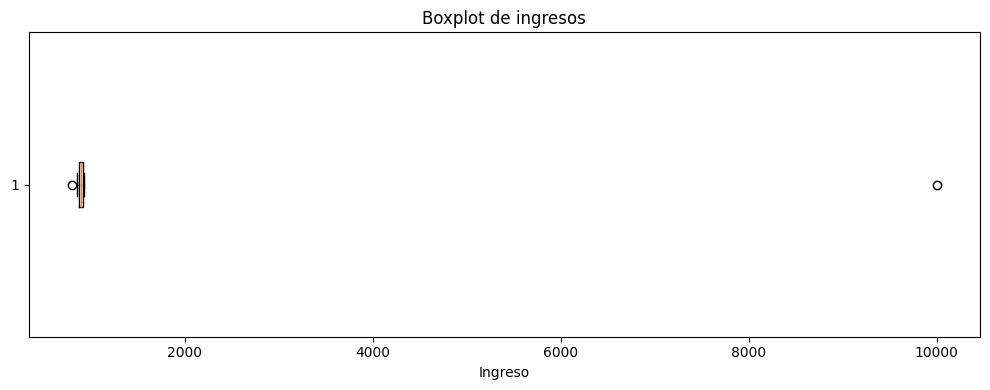

In [4]:
# 3) Boxplot + líneas de referencia

plt.figure(figsize=(10, 4))
plt.boxplot(s, vert=False, showfliers=True)
plt.title("Boxplot de ingresos")
plt.xlabel("Ingreso")
plt.tight_layout()
plt.show()


In [5]:
# 4) Preguntas para el mini-debate (media vs mediana)
mediana = s.median()
print("\nImpacto en medidas de tendencia central")
print(f"Media: {s.mean():.2f}")
print(f"Mediana: {mediana:.2f}")


Impacto en medidas de tendencia central
Media: 1897.78
Mediana: 900.00
